In [1]:
# VaR Risk Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
n = 500

price = 20000

prices = []

for i in range(n):

    price = price * (1 + np.random.normal(0, 0.01))

    prices.append(price)

df = pd.DataFrame({
    "price": prices
})

df.head()

,price
0,20292.420639
1,19988.780493
2,19985.105247
3,20006.796292
4,19968.333331


In [4]:
df["time"] = pd.date_range(
    "2024-01-01",
    periods=n,
    freq="H"
)

df.head()

/tmp/ipykernel_307/3554975379.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["time"] = pd.date_range(


,price,time
0,20292.420639,2024-01-01 00:00:00
1,19988.780493,2024-01-01 01:00:00
2,19985.105247,2024-01-01 02:00:00
3,20006.796292,2024-01-01 03:00:00
4,19968.333331,2024-01-01 04:00:00


In [5]:
df["return"] = df["price"].pct_change()

df.head()

,price,time,return
0,20292.420639,2024-01-01 00:00:00,NaN
1,19988.780493,2024-01-01 01:00:00,-0.014963
2,19985.105247,2024-01-01 02:00:00,-0.000184
3,20006.796292,2024-01-01 03:00:00,0.001085
4,19968.333331,2024-01-01 04:00:00,-0.001922


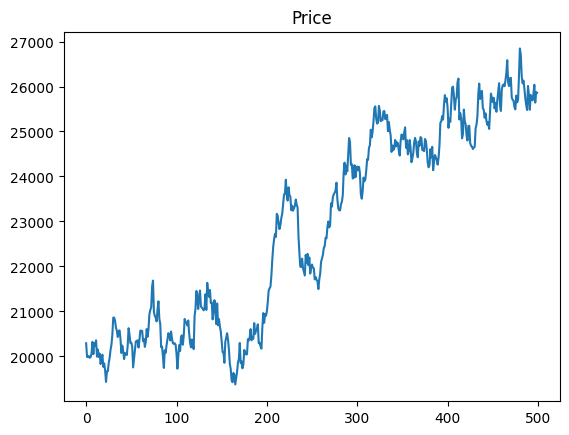

In [6]:
plt.plot(df["price"])

plt.title("Price")

plt.show()

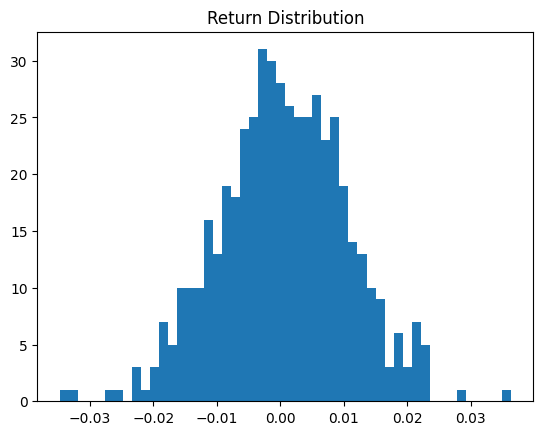

In [7]:
plt.hist(df["return"].dropna(), bins=50)

plt.title("Return Distribution")

plt.show()

In [8]:
position = 10

df["position"] = position

In [9]:
df["pnl"] = df["position"] * df["return"]

df.head()

,price,time,return,position,pnl
0,20292.420639,2024-01-01 00:00:00,NaN,10,NaN
1,19988.780493,2024-01-01 01:00:00,-0.014963,10,-0.149632
2,19985.105247,2024-01-01 02:00:00,-0.000184,10,-0.001839
3,20006.796292,2024-01-01 03:00:00,0.001085,10,0.010854
4,19968.333331,2024-01-01 04:00:00,-0.001922,10,-0.019225


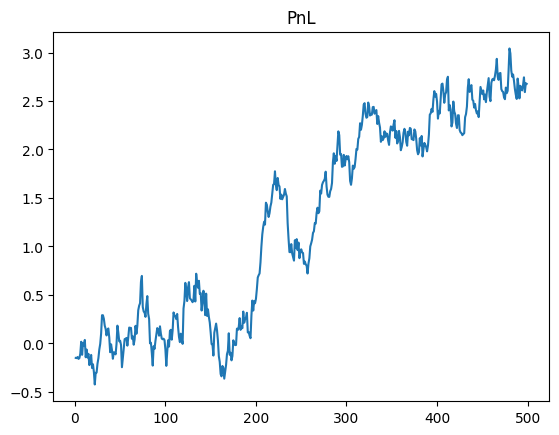

In [10]:
df["cum_pnl"] = df["pnl"].cumsum()

plt.plot(df["cum_pnl"])

plt.title("PnL")

plt.show()

In [11]:
df["vol"] = df["return"].rolling(20).std()

df.head()

,price,time,return,position,pnl,cum_pnl,vol
0,20292.420639,2024-01-01 00:00:00,NaN,10,NaN,NaN,NaN
1,19988.780493,2024-01-01 01:00:00,-0.014963,10,-0.149632,-0.149632,NaN
2,19985.105247,2024-01-01 02:00:00,-0.000184,10,-0.001839,-0.151471,NaN
3,20006.796292,2024-01-01 03:00:00,0.001085,10,0.010854,-0.140617,NaN
4,19968.333331,2024-01-01 04:00:00,-0.001922,10,-0.019225,-0.159842,NaN


In [12]:
var95 = df["pnl"].quantile(0.05)

var95

np.float64(-0.1609153706513622)

In [13]:
var99 = df["pnl"].quantile(0.01)

var99

np.float64(-0.22778674524919923)

In [15]:
df["rolling_var"] = (
    df["pnl"]
    .rolling(50)
    .quantile(0.05)
)

df.tail()

,price,time,return,position,pnl,cum_pnl,vol,rolling_var
495,25834.099935,2024-01-21 15:00:00,0.005579,10,0.055794,2.664919,0.011589,-0.172548
496,26038.469159,2024-01-21 16:00:00,0.007911,10,0.079108,2.744027,0.011415,-0.172548
497,25642.177543,2024-01-21 17:00:00,-0.015219,10,-0.152195,2.591832,0.011876,-0.172548
498,25876.437150,2024-01-21 18:00:00,0.009136,10,0.091357,2.683190,0.012040,-0.172548
499,25859.952577,2024-01-21 19:00:00,-0.000637,10,-0.006370,2.676819,0.011073,-0.172548


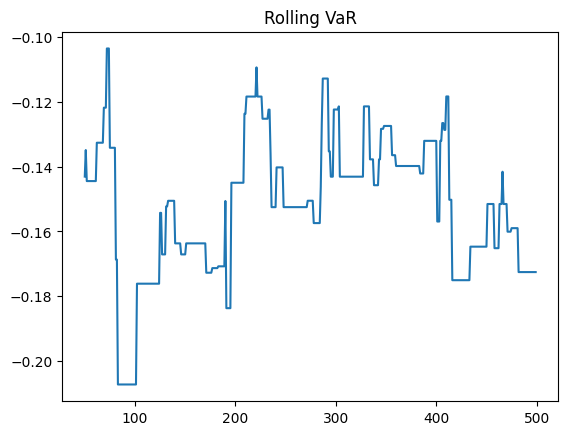

In [16]:
plt.plot(df["rolling_var"].dropna())

plt.title("Rolling VaR")

plt.show()

In [17]:
shock = -0.2

df["stress_pnl"] = df["position"] * shock

df["stress_pnl"].head()

,stress_pnl
0,-2.0
1,-2.0
2,-2.0
3,-2.0
4,-2.0


In [20]:
shock_price = df["price"] * 0.8

stress_return = shock_price / df["price"] - 1

df["stress_pnl"] = df["position"] * stress_return

In [21]:
print("VaR95:", var95)

print("VaR99:", var99)

print("Max loss:", df["pnl"].min())

VaR95: -0.1609153706513622
VaR99: -0.22778674524919923
Max loss: -0.34697727053504157
